# Treinamento de Machine Learning

In [41]:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.linear_model import SGDClassifier, LinearRegression
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, root_mean_squared_error, mean_squared_error, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, StratifiedKFold


import numpy as np

## Problema de classificação

Carregando os dados, separando vairáveis independentes das dependentes

In [42]:
dataset = load_iris()

x = dataset.data
y = dataset.target

Separação 80% para treino e 20% para teste

In [43]:
X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

Instanciando e treinando modelo

In [44]:
model = svm.SVC()
model.fit(X_treino, y_treino)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Avaliando modelo:

In [45]:
result = model.predict(X_teste)

print(accuracy_score(y_teste, result))
print(f1_score(y_teste, result, average="micro"))
cm = confusion_matrix(y_teste, result)
print(confusion_matrix(y_teste, result))

1.0
1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


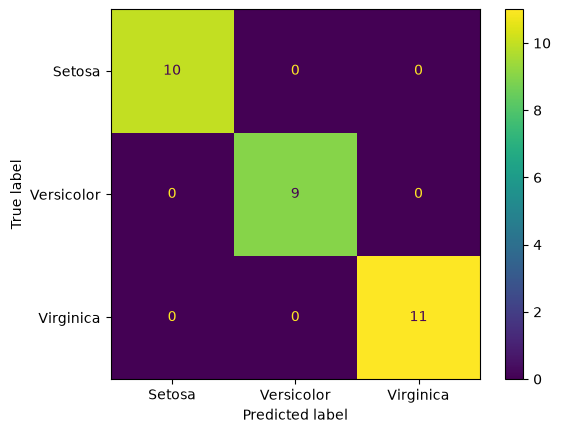

In [10]:
disp = ConfusionMatrixDisplay(cm, display_labels=["Setosa", "Versicolor", "Virginica"])
disp.plot()

Utilizando KFold para treinar e avaliar o modelo

In [39]:
kf = StratifiedKFold(n_splits=5, shuffle=True)
model = svm.SVC()
acc = []
f1score = []
for i, (train_index, test_index) in enumerate(kf.split(x, y)):
    # print(f"fold {i + 1}: {y[test_index]}")
    model.fit(x[train_index], y[train_index])
    result = model.predict(x[test_index])
    acc_f = accuracy_score(y[test_index], result)
    f1s_f = f1_score(y[test_index], result, average="macro")
    acc.append(acc_f)
    f1score.append(f1s_f)
    # print(f"fold {i + 1}:")
    # print(f"acc: {acc_f}")
    # print(f"f1score: {f1s_f}\n")

print(f"média acc: {np.mean(acc)}")
print(f"média f1_score: {np.mean(f1score)}")

média acc: 0.96
média f1_score: 0.9597306397306398
